In [1]:
pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 705.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 10.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


# Word to Vector: Representing Words as Numbers

Word to Vector (Word2Vec) is a groundbreaking technique in natural language processing that transforms words into numerical vectors in a high-dimensional space. This representation allows machines to understand semantic relationships between words mathematically.

## Core Concept

At its heart, Word2Vec converts words from human language into dense numerical vectors. Unlike traditional one-hot encoding which treats each word as an isolated entity, Word2Vec captures semantic and syntactic relationships between words. Words with similar meanings cluster together in the vector space.

## How It Works

Word2Vec uses neural networks to learn word associations from large text corpora. There are two primary architectures:

1. **Continuous Bag of Words (CBOW)**: Predicts a target word from its surrounding context words
2. **Skip-gram**: Predicts the surrounding context words given a target word

The training process adjusts word vectors so that words occurring in similar contexts have similar vectors. After training, these vectors capture remarkable relationships, such as:

- king - man + woman ≈ queen
- paris - france + italy ≈ rome

## Applications

Word2Vec has revolutionized numerous NLP applications:
- Document classification
- Sentiment analysis
- Recommendation systems
- Machine translation
- Question answering

## Implementation

A basic implementation of Word2Vec requires:

```python
# Import necessary libraries
import gensim
from gensim.models import Word2Vec

# Prepare your corpus (list of tokenized sentences)
sentences = [["cat", "sat", "on", "the", "mat"], ["dog", "barked", "at", "the", "cat"], ...]

# Train the model
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Access word vectors
cat_vector = model.wv['cat']

# Find similar words
similar_words = model.wv.most_similar('cat')
```

## Advantages

- **Dimensionality reduction**: Represents words in a dense vector space
- **Semantic relationships**: Captures word similarities and relationships
- **Transferable knowledge**: Pre-trained vectors can be used across different NLP tasks
- **Improved performance**: Enhances accuracy in various NLP applications

## Limitations

- Cannot handle out-of-vocabulary words
- Static embeddings don't account for context-dependent meanings
- Requires large amounts of training data for effective results

## Conclusion

By transforming words into mathematical objects, Word2Vec has helped bridge the gap between human language and machine understanding, becoming a fundamental building block in modern natural language processing systems. While newer techniques like contextual embeddings (BERT, GPT) have expanded on its capabilities, Word2Vec remains an important milestone in the evolution of NLP.

In [2]:
import nltk
import gensim
import string
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import numpy as np
import re

In [16]:
nltk.download('punkt_tab')
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
corpus =  [
"LLMs help doctors summarize medical records and research findings more efficiently.",
"LLMs are used in education to create personalized learning materials for students.",
"Customer service teams use LLMs to generate helpful responses to common inquiries.",
"LLMs are revolutionizing the way people interact with their digital devices.",
"LLM-based code assistants improve programmer productivity and code quality.",
"The use of LLMs in language translation helps bridge communication gaps globally.",
"LLMs are shaping the future of creative writing and collaborative storytelling.",
"LLM-powered search engines help users find more contextually relevant information.",
"The entertainment industry uses LLMs to assist in script development and analysis.",
"LLMs in marketing enhance content creation and audience engagement strategies.",
"Digital assistants powered by LLMs help users manage their daily schedules more effectively.",
"The role of LLMs in scientific research accelerates literature review and hypothesis generation.",
"LLMs are helping historians analyze and interpret historical texts and documents.",
"LLMs in legal practice aid in contract analysis and legal document preparation.",
"LLM-driven content moderation is transforming online community management.",
"LLM-powered accessibility tools enhance digital experiences for people with disabilities."
]


In [5]:
s = "my name is nahiyan noor 162 12832  ."
s.lower()

'my name is nahiyan noor 162 12832  .'

In [12]:
s = re.sub(r'\d+',"",s)

In [13]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
s.translate(str.maketrans("","",string.punctuation))

'my name is nahiyan noor    '

In [17]:
word_tokenize(s)

['my', 'name', 'is', 'nahiyan', 'noor', '.']

In [18]:
s1 = ['my', 'name', 'is', 'nahiyan', 'noor', '162', '12832', '.']

In [19]:
[ i for i in s1 if i not in stopwords.words('english')]

['name', 'nahiyan', 'noor', '162', '12832', '.']

In [20]:
def word_prepprocessing(text) :
    text = text.lower()
    text = re.sub(r'\d+',"",text)
    text = text.translate(str.maketrans("","",string.punctuation))
    word = word_tokenize(text)
    word = [ i for i in word if i not in stopwords.words('english')]
    return word

In [21]:
corpus

['LLMs help doctors summarize medical records and research findings more efficiently.',
 'LLMs are used in education to create personalized learning materials for students.',
 'Customer service teams use LLMs to generate helpful responses to common inquiries.',
 'LLMs are revolutionizing the way people interact with their digital devices.',
 'LLM-based code assistants improve programmer productivity and code quality.',
 'The use of LLMs in language translation helps bridge communication gaps globally.',
 'LLMs are shaping the future of creative writing and collaborative storytelling.',
 'LLM-powered search engines help users find more contextually relevant information.',
 'The entertainment industry uses LLMs to assist in script development and analysis.',
 'LLMs in marketing enhance content creation and audience engagement strategies.',
 'Digital assistants powered by LLMs help users manage their daily schedules more effectively.',
 'The role of LLMs in scientific research accelerates

In [22]:
processed_corpus = [word_prepprocessing(sentence) for sentence in corpus]

In [23]:
processed_corpus

[['llms',
  'help',
  'doctors',
  'summarize',
  'medical',
  'records',
  'research',
  'findings',
  'efficiently'],
 ['llms',
  'used',
  'education',
  'create',
  'personalized',
  'learning',
  'materials',
  'students'],
 ['customer',
  'service',
  'teams',
  'use',
  'llms',
  'generate',
  'helpful',
  'responses',
  'common',
  'inquiries'],
 ['llms',
  'revolutionizing',
  'way',
  'people',
  'interact',
  'digital',
  'devices'],
 ['llmbased',
  'code',
  'assistants',
  'improve',
  'programmer',
  'productivity',
  'code',
  'quality'],
 ['use',
  'llms',
  'language',
  'translation',
  'helps',
  'bridge',
  'communication',
  'gaps',
  'globally'],
 ['llms',
  'shaping',
  'future',
  'creative',
  'writing',
  'collaborative',
  'storytelling'],
 ['llmpowered',
  'search',
  'engines',
  'help',
  'users',
  'find',
  'contextually',
  'relevant',
  'information'],
 ['entertainment',
  'industry',
  'uses',
  'llms',
  'assist',
  'script',
  'development',
  'anal

In [31]:
word2vec_cbow = Word2Vec(sentences=processed_corpus ,vector_size=100 , window=10,min_count=1,sg=0)
word2vec_skipgram = Word2Vec(sentences=processed_corpus ,vector_size=100 , window=10,min_count=1,sg=1)

# cbow = generate a target word or next word2vec_cbow
# skipgram = generate a context word or previous word2vec_skipgram\

#Here window size is the window size that need to capture information from to generate next word. If the window size is larger, the model has ability to capture semantic relationship, and if the window size is smaller, then the model would get syntactic relationship.

In [35]:
word2vec_skipgram.wv['llms']

array([-5.3108681e-04,  3.2016097e-04,  5.0661825e-03,  8.9836633e-03,
       -9.2103556e-03, -7.1742726e-03,  6.4941631e-03,  9.0411818e-03,
       -4.9858331e-03, -3.7922733e-03,  7.3502450e-03, -1.5706370e-03,
       -4.5141242e-03,  6.5775444e-03, -4.8464909e-03, -1.8561734e-03,
        2.8278092e-03,  9.6978422e-04, -8.3611878e-03, -9.5580006e-03,
        7.3220646e-03,  5.0406777e-03,  6.7880643e-03,  7.6094235e-04,
        6.3639735e-03, -3.4282720e-03, -9.0682320e-04,  5.7451995e-03,
       -7.5829607e-03, -3.9630365e-03, -7.4966899e-03, -9.6141017e-04,
        9.5742885e-03, -7.3833363e-03, -2.3655351e-03, -1.8997098e-03,
        8.0789682e-03, -5.9799445e-03,  2.4734201e-05, -4.7663632e-03,
       -9.5937569e-03,  4.9522282e-03, -8.7850746e-03, -4.4025546e-03,
        2.4426608e-05, -3.4866881e-04, -7.6636742e-03,  9.5670391e-03,
        5.0887801e-03,  9.2885876e-03, -8.0842255e-03,  4.4711400e-03,
       -4.1160812e-03,  8.1857428e-04,  8.4528979e-03, -4.4315825e-03,
      

In [32]:
word2vec_skipgram.vector_size

100

In [37]:
word2vec_cbow.wv.similarity("llmpowered","llms")

0.09320646

In [38]:
word2vec_cbow.wv.index_to_key

['llms',
 'help',
 'digital',
 'legal',
 'users',
 'analysis',
 'enhance',
 'content',
 'assistants',
 'code',
 'people',
 'use',
 'llmpowered',
 'research',
 'learning',
 'programmer',
 'productivity',
 'records',
 'medical',
 'quality',
 'summarize',
 'language',
 'translation',
 'helps',
 'bridge',
 'communication',
 'gaps',
 'globally',
 'shaping',
 'future',
 'creative',
 'doctors',
 'writing',
 'collaborative',
 'improve',
 'personalized',
 'findings',
 'helpful',
 'create',
 'materials',
 'students',
 'customer',
 'service',
 'teams',
 'education',
 'generate',
 'responses',
 'llmbased',
 'common',
 'inquiries',
 'revolutionizing',
 'storytelling',
 'used',
 'interact',
 'efficiently',
 'devices',
 'way',
 'disabilities',
 'search',
 'aid',
 'hypothesis',
 'generation',
 'helping',
 'historians',
 'analyze',
 'interpret',
 'historical',
 'texts',
 'documents',
 'practice',
 'contract',
 'experiences',
 'document',
 'preparation',
 'llmdriven',
 'moderation',
 'transforming',
 'o

In [44]:

word2vec_cbow.wv.most_similar("document",topn=5)

[('llms', 0.29125741124153137),
 ('review', 0.28695395588874817),
 ('tools', 0.26837408542633057),
 ('improve', 0.21722739934921265),
 ('customer', 0.2125052660703659)]

In [42]:
word2vec_skipgram.wv.most_similar("productivity",topn=5)

[('efficiently', 0.23282893002033234),
 ('llms', 0.22146867215633392),
 ('relevant', 0.22143670916557312),
 ('community', 0.1992729902267456),
 ('review', 0.18784593045711517)]

In [ ]:
corpus

['AI-assisted legal research helps lawyers analyze case laws more efficiently.',
 'AI is used in astronomy to analyze vast amounts of cosmic data.',
 'Smart homes use AI for automation and energy efficiency.',
 'AI is revolutionizing the way people search for information online.',
 'AI-based handwriting recognition improves digitization and document processing.',
 'The use of AI in wildlife conservation helps monitor endangered species.',
 'AI is shaping the future of content creation in journalism and storytelling.',
 'AI-driven job matching platforms help connect candidates with suitable employers.',
 'The financial sector uses AI to assess credit risk and detect fraudulent transactions.',
 'AI in manufacturing enhances efficiency and reduces production errors.',
 'Wearable technology powered by AI helps monitor personal health metrics.',
 'The role of AI in sports analytics improves team performance analysis.',
 'AI is helping researchers discover new materials and chemical compound

In [45]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

In [46]:
word_vectors = word2vec_cbow.wv
vocab = list(word_vectors.index_to_key)

In [47]:
len(vocab)

108

In [48]:
x = np.array([word_vectors[i] for i in vocab])

In [49]:
tsne = TSNE(n_components=2)

In [50]:
x_new_embedings = tsne.fit_transform(x)

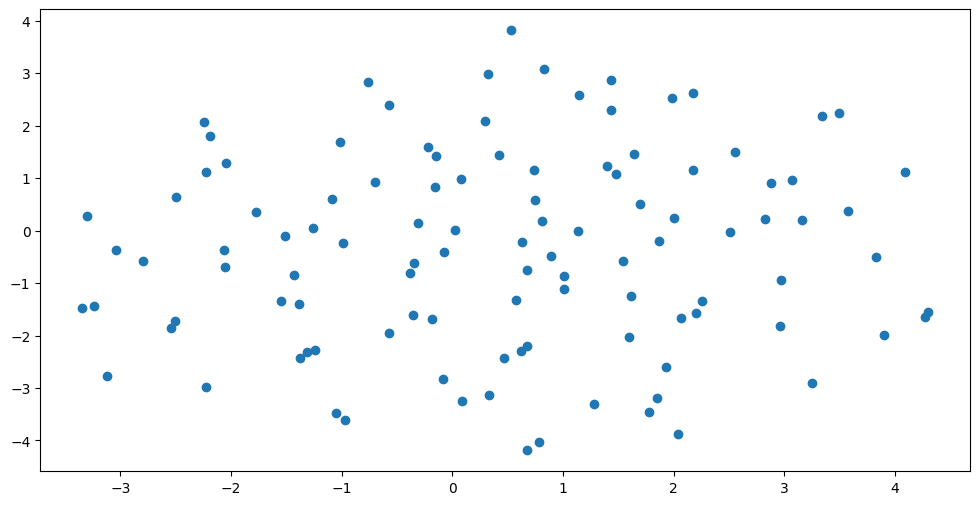

In [51]:
plt.figure(figsize=(12,6))
plt.scatter(x_new_embedings[: , 0] , x_new_embedings[:,1] , marker='o')

In [58]:
len(vocab)

108

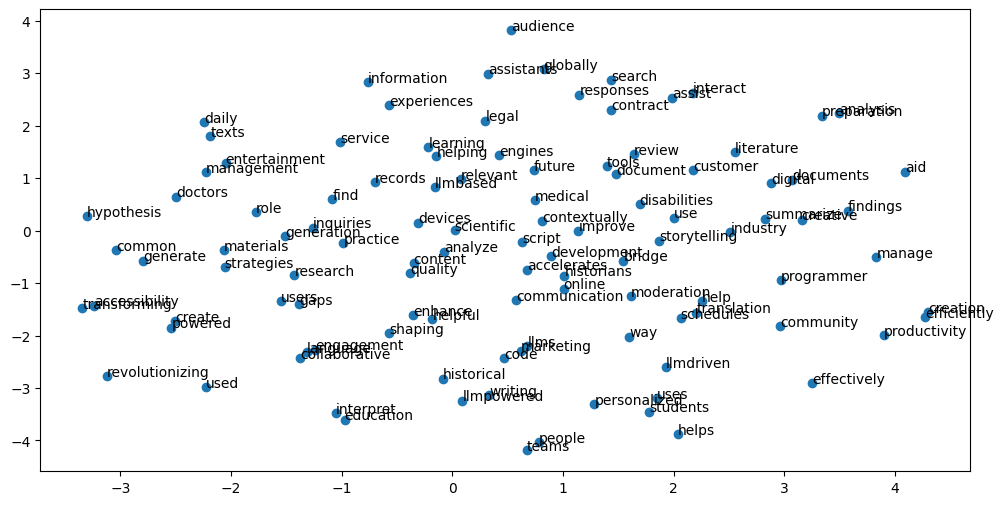

In [53]:
plt.figure(figsize=(12,6))
plt.scatter(x_new_embedings[: , 0] , x_new_embedings[:,1] , marker='o')

for i ,words in enumerate(vocab[:len(x_new_embedings)]):
    plt.annotate(words,xy=(x_new_embedings[i,0],x_new_embedings[i,1]))
plt.show()

In [60]:
text = "Barack Obama was the 44th President of the United States."

In [61]:
word_tokenize(text)

['Barack',
 'Obama',
 'was',
 'the',
 '44th',
 'President',
 'of',
 'the',
 'United',
 'States',
 '.']

In [62]:
from nltk import ne_chunk,pos_tag

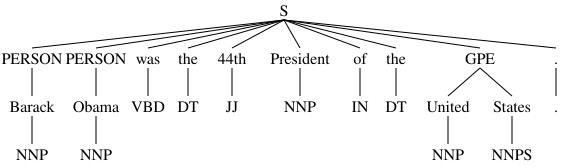

In [72]:
ne_chunk(pos_tag(word_tokenize(text)))

In [77]:
!pip install transformers

In [78]:
import transformers

In [79]:
!git config --global user.email "nahiyan.cuet@gmail.com"


In [80]:
!git config --global user.name "Nahiyan140212"

In [81]:
!git add .

fatal: not a git repository (or any of the parent directories): .git
